# Week 6 with new API interface

In [84]:
import jax
jax.config.update("jax_enable_x64", True) 

In [85]:
from src.api.v5 import (
    GaussEmission, 
    StaticTransition, 
    Params, 
    LBFGSSolver, 
    AutoregressiveGaussEmission, 
    MultivariateAutoregressiveGaussEmission, 
    MultivariateGaussEmission
    )
from drivers.utils import load_y_df, build_covariates, harmonic_range
import numpy as np
import jax.numpy as jnp
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
  

In [86]:

ROOM_SLUG, TAG  = "room_001", "30min"  


ys_train_df = load_y_df(ROOM_SLUG, TAG, "train")  # the driver's X_*.csv are not used: 

ys_train_df = ys_train_df.set_index("datetime").sort_index()  # sort by datetime, just in case 

print(f"Loaded {ROOM_SLUG}/{TAG} — {ys_train_df.shape[0]} training observations") 
print(f"First 5 rows of training data:\n{ys_train_df.head()}")

Loaded room_001/30min — 2752 training observations
First 5 rows of training data:
                            co2  humidity
datetime                                 
2023-11-13 04:00:00  502.786667  2.945788
2023-11-13 04:30:00  472.413333  2.945788
2023-11-13 05:00:00  493.706667  2.743398
2023-11-13 05:30:00  498.000000  2.743398
2023-11-13 06:00:00  481.293333  2.919637


In [87]:
@dataclass(frozen=True)
class Data:
    ys: jnp.ndarray
    datetime: np.ndarray
    ys_co2: jnp.ndarray
    ys_humidity: jnp.ndarray
    ys_cols: tuple[str] = ("co2", "humidity") # type: ignore



traindata = Data(
    ys=jnp.array(ys_train_df.values),
    datetime=ys_train_df.index.to_numpy(),
    ys_co2=jnp.array(ys_train_df["co2"].values),
    ys_humidity=jnp.array(ys_train_df["humidity"].values),
    ys_cols=tuple(ys_train_df.columns)
)

## Data plots of CO2 and Humidity

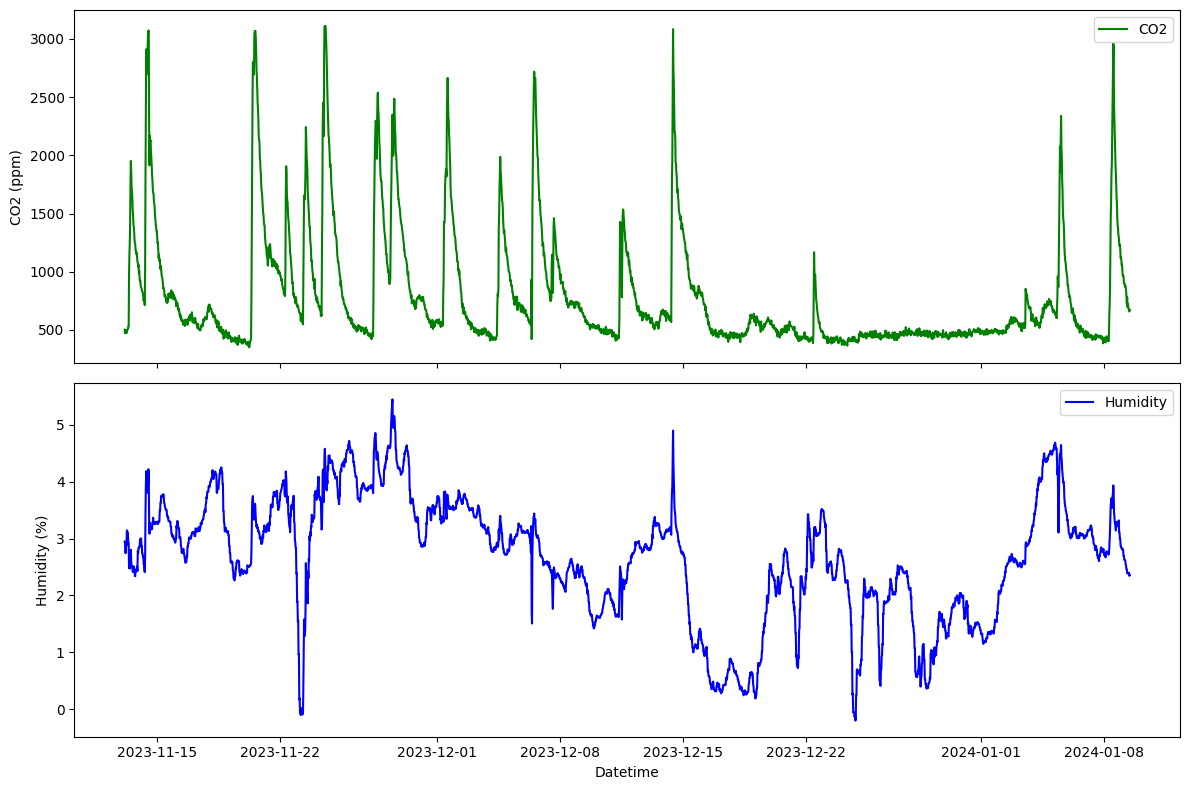

In [88]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axs[0].plot(traindata.datetime, traindata.ys_co2, label="CO2", color="green")
axs[0].set_ylabel("CO2 (ppm)")
axs[0].legend()
axs[1].plot(traindata.datetime, traindata.ys_humidity, label="Humidity", color="blue")
axs[1].set_ylabel("Humidity (%)")
axs[1].set_xlabel("Datetime")
axs[1].legend()
plt.tight_layout()

In [89]:
correl = ys_train_df.corr()

print(f"Correlation between CO2 and Humidity:\n{correl}")

Correlation between CO2 and Humidity:
               co2  humidity
co2       1.000000  0.424673
humidity  0.424673  1.000000


Correlation between standardized CO2 and Humidity: 0.4247


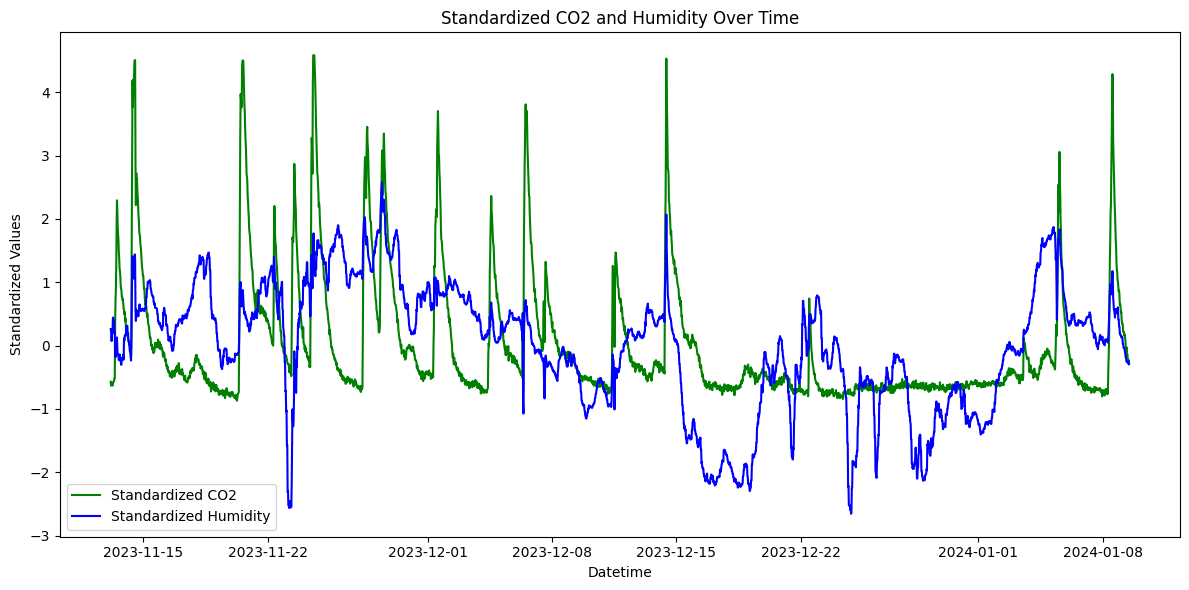

In [90]:
def standardise(x: jnp.ndarray) -> tuple:
    """Standardise a 1D array to have mean 0 and std 1."""
    mean = jnp.mean(x)
    std = jnp.std(x)
    z = (x - mean) / std
    return z, mean, std 


stand_co2, mean_co2, std_co2 = standardise(traindata.ys_co2)
stand_humidity, mean_hum, std_hum = standardise(traindata.ys_humidity)

correl_stand = jnp.corrcoef(stand_co2, stand_humidity)[0, 1] 


#Plot standardized CO2 and Humidity together
plt.figure(figsize=(12, 6))
plt.plot(traindata.datetime, stand_co2, label="Standardized CO2", color="green")
plt.plot(traindata.datetime, stand_humidity, label="Standardized Humidity", color="blue")
plt.ylabel("Standardized Values")
plt.xlabel("Datetime")
plt.title("Standardized CO2 and Humidity Over Time")
plt.legend()
plt.tight_layout()



print(f"Correlation between standardized CO2 and Humidity: {correl_stand:.4f}")

# Fitting 

In [91]:
def negative_likelihood(params: Params, data: tuple) -> jax.Array:
    """Compute the negative log-likelihood of the HMM given the parameters and data."""
    from src.api.v5 import ForwardAlgorithm 
    ys, xs, inital_dist = data
    utt, f_t, u_t = ForwardAlgorithm().run(params=params, ys=ys, xs=xs, initial_dist=inital_dist)  
    val = -jnp.sum(jnp.log(f_t))  # negative log-likelihood
    return val 
    


def compute_stationary_distribution(transition_matrix: jnp.ndarray) -> jnp.ndarray:
    """Compute the stationary distribution of a Markov chain given its transition matrix."""
    num_states = transition_matrix.shape[0]
    I = jnp.eye(num_states)
    E = jnp.ones((num_states, num_states))
    e = jnp.ones((num_states, 1))
    delta = e.T @ jnp.linalg.inv(I - transition_matrix + E)
    return delta / jnp.sum(delta)  # Normalize to sum to 1


In [92]:
#Seeding data
STATES = 4 

mu_seed = jnp.quantile(traindata.ys_co2, jnp.linspace(0.05, 0.95, STATES), axis=0)  # initial guess for means
std_seed = jnp.std(traindata.ys_co2, axis=0) * jnp.ones((STATES, ))  # initial guess for stds 
emission = GaussEmission.from_params(mu=mu_seed, sigma=std_seed)  # emission distribution


transition_matrix = jnp.diag(jnp.ones(STATES)) * 0.7 + jnp.ones((STATES, STATES)) * 0.3 / STATES  # initial guess for transition matrix
transition = StaticTransition.from_params(transition_matrix=transition_matrix)  # transition distribution


inital_dist = compute_stationary_distribution(transition_matrix)  # initial distribution: stationary distribution of the transition matrix
#inital_dist = jnp.ones((1 ,STATES)) / STATES  # initial distribution: uniform distribution over states

data = (traindata.ys_co2, None, inital_dist)  # initial distribution: all in state 0

## Fitting Univariate Model

### HMM(1)

In [93]:


emission = GaussEmission.from_params(mu=mu_seed, sigma=std_seed)  # emission distribution
transition = StaticTransition.from_params(transition_matrix=transition_matrix)  # transition distribution
gauss_params = Params(emission=emission, transition=transition)  # combine into Params object



solver = LBFGSSolver(n_iter=15000)

results = solver.fit(params=gauss_params, loss_fn=negative_likelihood, data=data)  # solve for parameters
fitted_gauss_params = results.params  # fitted parameters
print(f"Final loss: {results.loss}")
print(f"Converged: {results.converged}")
print(f"Estimated mu0: {results.params.emission.mu0}")

Final loss: 16450.473108563277
Converged: True
Estimated mu0: 419.64615838166236


In [94]:
def profile_likehood_mu0(mu0_range: jnp.ndarray, params: Params, data: tuple) -> jnp.ndarray:
    """Profile the negative log-likelihood over a range of mu0 values."""
    profile_likelihoods = []
    solver = LBFGSSolver(n_iter=1000)

    for mu0 in mu0_range:
        # Create new Params with updated mu0
        emission = params.emission.update_param(param_name="mu0", new_value=mu0, index=None)
        params = Params(emission=emission, transition=params.transition)
        results = solver.fit(params=params, loss_fn=negative_likelihood, data=data)  # solve for parameters
        params = results.params  # get the fitted parameters
        nll = results.loss

        profile_likelihoods.append(nll)
    
    return jnp.array(profile_likelihoods)

In [95]:
mu0_range = jnp.linspace(results.params.emission.mu0 - 0.1, results.params.emission.mu0  + 0.1, 40)  # range of mu0 values to profile

nll = profile_likehood_mu0(mu0_range, results.params, data)

Text(0, 0.5, 'Likelihood')

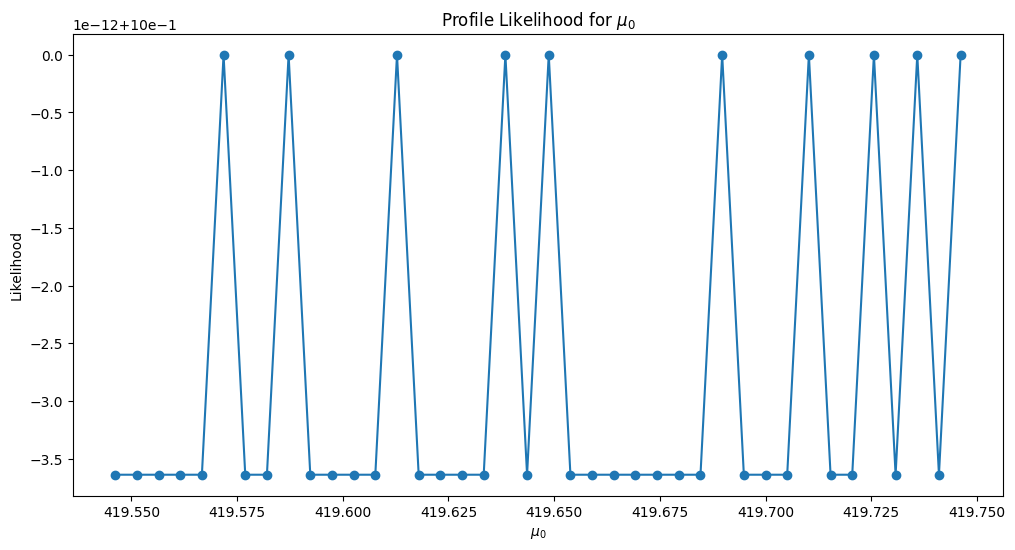

In [97]:
#Plot profile likelihood
ll = -nll  # Convert negative log-likelihood to log-likelihood for plotting
profile_likelihoods = jnp.exp(ll - jnp.max(ll))  # Convert negative log-likelihood to likelihood for plotting
plt.figure(figsize=(12, 6))
plt.plot(mu0_range, profile_likelihoods, marker='o')
plt.title("Profile Likelihood for $\mu_0$")
plt.xlabel("$\mu_0$")
plt.ylabel("Likelihood")

### AR(1)-HMM(1)

In [98]:
phi = jnp.ones(STATES) * 0.1
mu=fitted_gauss_params.emission.mu(t=0, ys=0)
std = fitted_gauss_params.emission.sigma(t=0, ys=0)


In [99]:

emission = AutoregressiveGaussEmission.from_params(mu=mu, sigma=std, phi=phi)  # emission distribution
transition = fitted_gauss_params.transition  # transition distribution 

ar1_params = Params(emission=emission, transition=transition)  # combine into Params object 

results_ar1 = solver.fit(params=ar1_params, loss_fn=negative_likelihood, data=data)  # solve for parameters

print(f"Final loss for AR(1)-HMM(1): {results_ar1.loss}")
print(f"Converged: {results_ar1.converged}")

Final loss for AR(1)-HMM(1): 13322.612529688988
Converged: True
